In [1]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_PATH = "../data/classification/train"
VAL_PATH = "../data/classification/val"

train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1750 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [3]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [4]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [5]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.1246 - loss: 3.0881 - val_accuracy: 0.0373 - val_loss: 3.3392
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.3389 - loss: 2.4760 - val_accuracy: 0.0373 - val_loss: 3.2817
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.4531 - loss: 2.0226 - val_accuracy: 0.0400 - val_loss: 3.2404
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.5657 - loss: 1.6369 - val_accuracy: 0.0960 - val_loss: 3.1494
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.6326 - loss: 1.3636 - val_accuracy: 0.1627 - val_loss: 3.0087
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.7006 - loss: 1.1320 - val_accuracy: 0.3253 - val_loss: 2.5416
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.7411 - loss: 0.9464 - val_accuracy: 0.4000 - val_loss: 2.3681
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.8086 - loss: 0.7644 - val_accuracy: 0.5467 - v

In [8]:
model.save("../models/resnet50_model.h5")
print("ResNet Model Saved ✅")

ResNet Model Saved ✅


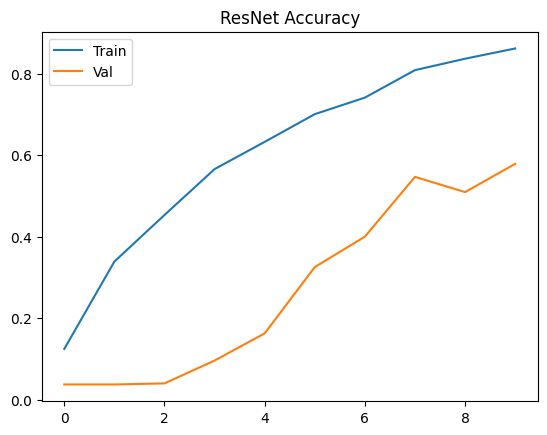

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("ResNet Accuracy")
plt.legend(["Train","Val"])
plt.show()